Found 5 task folders


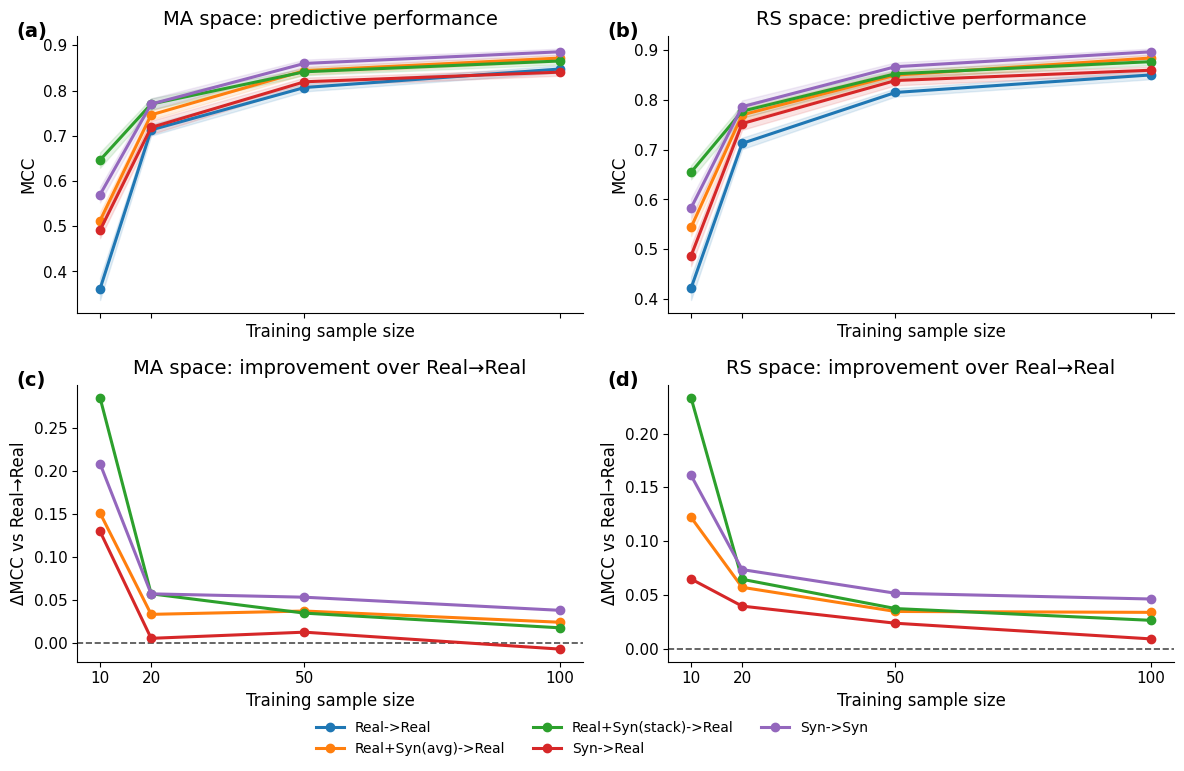

In [7]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Settings
# -----------------------------
base_dir = "../dashboard/backend/results/5_CombinedModel/"
task_pattern = "NB_Ablation_Size_50_Run_*"

platform_files = {
    "MA": "Classifier_Performance_Combined_GANomics_MA.csv",
    "RS": "Classifier_Performance_Combined_GANomics_RS.csv",
}

scenario_order = [
    "Real->Real",
    "Real+Syn(avg)->Real",
    "Real+Syn(stack)->Real",
    "Syn->Real",
    "Syn->Syn",
]

scenario_colors = {
    "Real->Real": "#1f77b4",
    "Real+Syn(avg)->Real": "#ff7f0e",
    "Real+Syn(stack)->Real": "#2ca02c",
    "Syn->Real": "#d62728",
    "Syn->Syn": "#9467bd",
}

metric = "MCC"

# -----------------------------
# Load all results
# -----------------------------
all_rows = []

task_dirs = sorted(glob.glob(os.path.join(base_dir, task_pattern)))
print(f"Found {len(task_dirs)} task folders")

for task_dir in task_dirs:
    task_name = os.path.basename(task_dir)

    for platform, filename in platform_files.items():
        fpath = os.path.join(task_dir, filename)
        if not os.path.exists(fpath):
            print(f"Missing: {fpath}")
            continue

        df = pd.read_csv(fpath)
        df["Task"] = task_name
        df["Platform"] = platform
        all_rows.append(df)

if not all_rows:
    raise ValueError("No result files found.")

df_all = pd.concat(all_rows, ignore_index=True)
df_all = df_all[df_all["Scenario"].isin(scenario_order)].copy()

for col in ["Train_Size_Base", "Train_N_Actual", "Repeat", metric]:
    if col in df_all.columns:
        df_all[col] = pd.to_numeric(df_all[col], errors="coerce")

# Keep only train sizes that are present in the results
available_sizes = sorted(df_all["Train_Size_Base"].dropna().unique())

# -----------------------------
# Summarize
# -----------------------------
summary = (
    df_all.groupby(["Platform", "Scenario", "Train_Size_Base"], as_index=False)
    .agg(
        Mean=(metric, "mean"),
        SD=(metric, "std"),
        N=(metric, "count"),
    )
)
summary["SE"] = summary["SD"] / np.sqrt(summary["N"])

baseline = (
    summary[summary["Scenario"] == "Real->Real"]
    .loc[:, ["Platform", "Train_Size_Base", "Mean"]]
    .rename(columns={"Mean": "BaselineMean"})
)

summary_delta = summary.merge(
    baseline,
    on=["Platform", "Train_Size_Base"],
    how="left"
)
summary_delta["Delta_vs_Real"] = summary_delta["Mean"] - summary_delta["BaselineMean"]

# -----------------------------
# Publication-ready figure
# -----------------------------
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
})

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex="col")
axes = axes.flatten()

panel_specs = [
    ("MA", False, "(a)", "MA space: predictive performance"),
    ("RS", False, "(b)", "RS space: predictive performance"),
    ("MA", True,  "(c)", "MA space: improvement over Real→Real"),
    ("RS", True,  "(d)", "RS space: improvement over Real→Real"),
]

for ax, (platform, is_delta, tag, subtitle) in zip(axes, panel_specs):
    if not is_delta:
        sub = summary[summary["Platform"] == platform]
        scenarios_to_plot = scenario_order
        ylab = metric
    else:
        sub = summary_delta[
            (summary_delta["Platform"] == platform) &
            (summary_delta["Scenario"] != "Real->Real")
        ]
        scenarios_to_plot = [
            "Real+Syn(avg)->Real",
            "Real+Syn(stack)->Real",
            "Syn->Real",
            "Syn->Syn",
        ]
        ylab = f"Δ{metric} vs Real→Real"
        ax.axhline(0, linestyle="--", linewidth=1.2, color="black", alpha=0.7)

    for scenario in scenarios_to_plot:
        s = sub[sub["Scenario"] == scenario].sort_values("Train_Size_Base")
        if s.empty:
            continue

        ax.plot(
            s["Train_Size_Base"],
            s["Mean"] if not is_delta else s["Delta_vs_Real"],
            marker="o",
            linewidth=2.2,
            markersize=6,
            color=scenario_colors[scenario],
            label=scenario
        )

        if not is_delta:
            ax.fill_between(
                s["Train_Size_Base"],
                s["Mean"] - s["SE"],
                s["Mean"] + s["SE"],
                color=scenario_colors[scenario],
                alpha=0.12
            )

    ax.set_title(subtitle, pad=8)
    ax.set_xlabel("Training sample size")
    ax.set_ylabel(ylab)
    ax.set_xticks(available_sizes)

    ax.grid(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # panel tag
    ax.text(
        -0.12, 1.05, tag,
        transform=ax.transAxes,
        fontsize=14,
        fontweight="bold",
        va="top",
        ha="left"
    )

# Shared legends: one for top row, one for bottom row
handles_top, labels_top = axes[0].get_legend_handles_labels()
handles_bottom, labels_bottom = axes[2].get_legend_handles_labels()

fig.legend(
    handles_top, labels_top,
    loc="lower center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, 0.03)
)

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

In [8]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_rel, wilcoxon

metric = "MCC"

compare_scenarios = [
    "Real+Syn(avg)->Real",
    "Real+Syn(stack)->Real",
    "Syn->Real",
    "Syn->Syn",
]

# Keep only needed columns
df_stats = df_all[
    ["Task", "Platform", "Train_Size_Base", "Repeat", "Scenario", metric]
].copy()

# Pivot so each scenario is a column
df_wide = df_stats.pivot_table(
    index=["Task", "Platform", "Train_Size_Base", "Repeat"],
    columns="Scenario",
    values=metric
).reset_index()

results = []

for platform in sorted(df_wide["Platform"].dropna().unique()):
    for train_size in sorted(df_wide["Train_Size_Base"].dropna().unique()):
        sub = df_wide[
            (df_wide["Platform"] == platform) &
            (df_wide["Train_Size_Base"] == train_size)
        ].copy()

        if "Real->Real" not in sub.columns:
            continue

        baseline = sub["Real->Real"]

        for scenario in compare_scenarios:
            if scenario not in sub.columns:
                continue

            tmp = sub[["Real->Real", scenario]].dropna()
            n = len(tmp)

            if n < 2:
                continue

            diff = tmp[scenario] - tmp["Real->Real"]

            # Paired t-test
            t_stat, t_p = ttest_rel(tmp[scenario], tmp["Real->Real"])

            # Wilcoxon signed-rank test
            try:
                w_stat, w_p = wilcoxon(tmp[scenario], tmp["Real->Real"])
            except ValueError:
                # Happens when all paired differences are zero
                w_stat, w_p = np.nan, np.nan

            results.append({
                "Platform": platform,
                "Train_Size_Base": train_size,
                "Scenario": scenario,
                "N_pairs": n,
                "Mean_Baseline": tmp["Real->Real"].mean(),
                "Mean_Scenario": tmp[scenario].mean(),
                "Mean_Diff": diff.mean(),
                "SD_Diff": diff.std(ddof=1),
                "t_stat": t_stat,
                "p_ttest": t_p,
                "w_stat": w_stat,
                "p_wilcoxon": w_p,
            })

pval_df = pd.DataFrame(results).sort_values(
    ["Platform", "Train_Size_Base", "Scenario"]
).reset_index(drop=True)

print("Paired significance tests vs Real->Real")
display(pval_df)

Paired significance tests vs Real->Real


,Platform,Train_Size_Base,Scenario,N_pairs,Mean_Baseline,Mean_Scenario,Mean_Diff,SD_Diff,t_stat,p_ttest,w_stat,p_wilcoxon
0,MA,10,Real+Syn(avg)->Real,50,0.361489,0.512503,0.151014,0.139681,7.644813,6.697199e-10,46.0,1.749137e-08
1,MA,10,Real+Syn(stack)->Real,50,0.361489,0.646280,0.284791,0.166198,12.116708,2.365727e-16,0.0,1.776357e-15
2,MA,10,Syn->Real,50,0.361489,0.491187,0.129698,0.178936,5.125341,5.025938e-06,199.0,7.946968e-06
3,MA,10,Syn->Syn,50,0.361489,0.569770,0.208281,0.157972,9.322975,1.956858e-12,27.0,3.784185e-09
4,MA,20,Real+Syn(avg)->Real,50,0.712916,0.746279,0.033364,0.071216,3.312707,1.741660e-03,311.0,1.282242e-03
5,MA,20,Real+Syn(stack)->Real,50,0.712916,0.770134,0.057219,0.072624,5.571127,1.063852e-06,142.0,2.865922e-06
6,MA,20,Syn->Real,50,0.712916,0.718452,0.005536,0.116842,0.335027,7.390350e-01,611.0,8.035270e-01
7,MA,20,Syn->Syn,50,0.712916,0.770080,0.057164,0.083353,4.849396,1.294101e-05,223.0,2.828307e-05
8,MA,50,Real+Syn(avg)->Real,50,0.806674,0.843885,0.037211,0.045964,5.724485,6.201963e-07,163.0,7.774230e-06
9,MA,50,Real+Syn(stack)->Real,50,0.806674,0.841461,0.034786,0.039258,6.265731,9.101837e-08,136.0,2.138386e-06


In [9]:
summary_table = pval_df.copy()
summary_table["sig_ttest"] = summary_table["p_ttest"].apply(
    lambda p: "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "ns"))
)
summary_table["sig_wilcoxon"] = summary_table["p_wilcoxon"].apply(
    lambda p: "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "ns"))
)

display(summary_table[
    [
        "Platform", "Train_Size_Base", "Scenario",
        "Mean_Baseline", "Mean_Scenario", "Mean_Diff",
        "p_ttest", "sig_ttest", "p_wilcoxon", "sig_wilcoxon"
    ]
])

,Platform,Train_Size_Base,Scenario,Mean_Baseline,Mean_Scenario,Mean_Diff,p_ttest,sig_ttest,p_wilcoxon,sig_wilcoxon
0,MA,10,Real+Syn(avg)->Real,0.361489,0.512503,0.151014,6.697199e-10,***,1.749137e-08,***
1,MA,10,Real+Syn(stack)->Real,0.361489,0.646280,0.284791,2.365727e-16,***,1.776357e-15,***
2,MA,10,Syn->Real,0.361489,0.491187,0.129698,5.025938e-06,***,7.946968e-06,***
3,MA,10,Syn->Syn,0.361489,0.569770,0.208281,1.956858e-12,***,3.784185e-09,***
4,MA,20,Real+Syn(avg)->Real,0.712916,0.746279,0.033364,1.741660e-03,**,1.282242e-03,**
5,MA,20,Real+Syn(stack)->Real,0.712916,0.770134,0.057219,1.063852e-06,***,2.865922e-06,***
6,MA,20,Syn->Real,0.712916,0.718452,0.005536,7.390350e-01,ns,8.035270e-01,ns
7,MA,20,Syn->Syn,0.712916,0.770080,0.057164,1.294101e-05,***,2.828307e-05,***
8,MA,50,Real+Syn(avg)->Real,0.806674,0.843885,0.037211,6.201963e-07,***,7.774230e-06,***
9,MA,50,Real+Syn(stack)->Real,0.806674,0.841461,0.034786,9.101837e-08,***,2.138386e-06,***


    Size    Scenario      mean       std  count
0     10  Real->Real  0.897962  0.016094     10
4     20  Real->Real  0.897679  0.026019     10
8     50  Real->Real  0.888324  0.020970     10
12   100  Real->Real  0.880659  0.048956     10
1     10   Real->Syn  0.541732  0.280701     10
5     20   Real->Syn  0.728167  0.105852     10
9     50   Real->Syn  0.857476  0.036660     10
13   100   Real->Syn  0.488537  0.347177     10
2     10   Syn->Real  0.552731  0.149239     10
6     20   Syn->Real  0.682710  0.123395     10
10    50   Syn->Real  0.840727  0.036398     10
14   100   Syn->Real  0.386400  0.287271     10
3     10    Syn->Syn  0.860613  0.050443     10
7     20    Syn->Syn  0.886562  0.029650     10
11    50    Syn->Syn  0.914801  0.049634     10
15   100    Syn->Syn  0.732938  0.213367     10


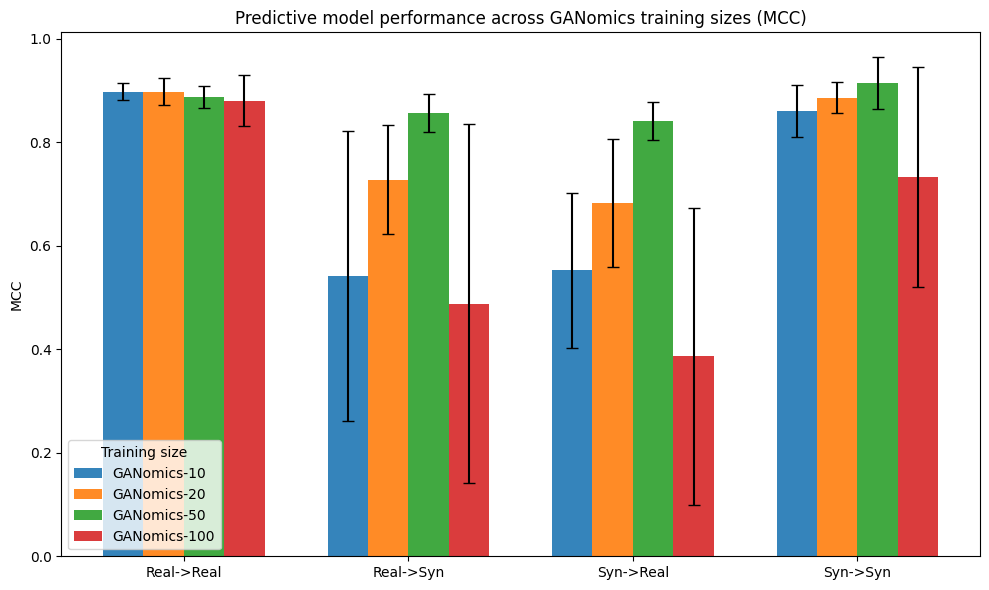

In [6]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Settings
# -----------------------------
base_dir = "/compute001/lwu/projects/GANomics/dashboard/backend/results_ms/4_Biomarkers/Prediction"

sizes = [10, 20, 50, 100]
reps = [0, 1, 2, 3, 4]

platform_files = {
    "MA": "Classifier_Performance_GANomics_MA.csv",
    "RS": "Classifier_Performance_GANomics_RS.csv",
}

metric = "MCC"

scenario_order = [
    "Real->Real",
    "Real->Syn",
    "Syn->Real",
    "Syn->Syn",
]

colors = {
    10: "#1f77b4",
    20: "#ff7f0e",
    50: "#2ca02c",
    100: "#d62728",
}

# -----------------------------
# Load data
# -----------------------------
all_results = []

for size in sizes:
    for rep in reps:
        folder = os.path.join(base_dir, f"NB_{size}_{rep}")

        for platform, fname in platform_files.items():
            file_path = os.path.join(folder, fname)

            if not os.path.exists(file_path):
                print(f"Missing: {file_path}")
                continue

            df = pd.read_csv(file_path)
            df.columns = [c.strip() for c in df.columns]

            # Try to standardize the scenario column
            if "Scenario" not in df.columns:
                possible_cols = [c for c in df.columns if "scenario" in c.lower()]
                if possible_cols:
                    df = df.rename(columns={possible_cols[0]: "Scenario"})
                else:
                    df = df.rename(columns={df.columns[0]: "Scenario"})

            # Check metric column
            if metric not in df.columns:
                print(f"Metric '{metric}' not found in: {file_path}")
                print("Columns:", list(df.columns))
                continue

            df["Size"] = size
            df["Rep"] = rep
            df["Platform"] = platform

            all_results.append(df[["Size", "Rep", "Platform", "Scenario", metric]])

if len(all_results) == 0:
    raise ValueError("No result files were loaded. Check folder names and CSV filenames.")

df_all = pd.concat(all_results, ignore_index=True)

# -----------------------------
# Optional: unify scenario names
# -----------------------------
scenario_map = {
    "Real->Real": "Real->Real",
    "Real->Synthetic": "Real->Syn",
    "Real->Syn": "Real->Syn",
    "Synthetic->Real": "Syn->Real",
    "Syn->Real": "Syn->Real",
    "Synthetic->Synthetic": "Syn->Syn",
    "Syn->Syn": "Syn->Syn",
}
df_all["Scenario"] = df_all["Scenario"].replace(scenario_map)

# Keep only wanted scenarios
df_all = df_all[df_all["Scenario"].isin(scenario_order)].copy()

# -----------------------------
# Aggregate over platforms + repeats
# -----------------------------
df_summary = (
    df_all.groupby(["Size", "Scenario"])[metric]
    .agg(["mean", "std", "count"])
    .reset_index()
)

df_summary["Scenario"] = pd.Categorical(
    df_summary["Scenario"],
    categories=scenario_order,
    ordered=True
)
df_summary = df_summary.sort_values(["Scenario", "Size"])

print(df_summary)

# -----------------------------
# Plot grouped bar chart
# -----------------------------
plt.figure(figsize=(10, 6))

x = np.arange(len(scenario_order))
bar_width = 0.18

for i, size in enumerate(sizes):
    sub = df_summary[df_summary["Size"] == size].set_index("Scenario").reindex(scenario_order)

    plt.bar(
        x + i * bar_width,
        sub["mean"],
        yerr=sub["std"],
        width=bar_width,
        capsize=4,
        label=f"GANomics-{size}",
        color=colors[size],
        alpha=0.9
    )

plt.xticks(x + bar_width * (len(sizes) - 1) / 2, scenario_order)
plt.ylabel(metric)
plt.title(f"Predictive model performance across GANomics training sizes ({metric})")
plt.legend(title="Training size")
plt.tight_layout()
plt.show()